In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

Matplotlib is building the font cache; this may take a moment.


Step 2.
- делим title на brand и model
- делаем нормальный color(там тоже приколы а-ля  Комплектация Action • Серый вот такое чиним)
- С помощью remove_outliers_iqr удаляем выбросы хз мб была какая-то чту из либы для этого но ладно

In [2]:
df = pd.read_csv('./data/cars_data.csv')
df = df.drop_duplicates()
df['mileage'] = df['mileage'].fillna(0)
df['brand'] = df['title'].str.split(',').str[0].str.split().str[0]
df['model'] = df['title'].str.split(',').str[0].str.split().str[1]
df['color_clean'] = df['color'].str.split('•').str[-1]

In [3]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

In [4]:
df_clean = remove_outliers_iqr(df, 'price')
df_clean = remove_outliers_iqr(df_clean, 'engine_power_hp')
df = df.drop(['title', 'color'], axis=1)

In [5]:
categorical_cols = ['brand', 'color_clean', 'body', 'wd', 'transmission', 'model']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

графики
- Можно сделать прикольные выводы
- Например что стоимость авто коррелирует с мощностью двигателя больше чем с его датой выпуска. Вроде неочев, а с другой стороны логично. Какой-нибудь dodge 2015 года на 900 сил будет явно дорогим + утильсбор, так что интересно будет посмотреть потом когда введут доп. пошлину на объём двигателя.

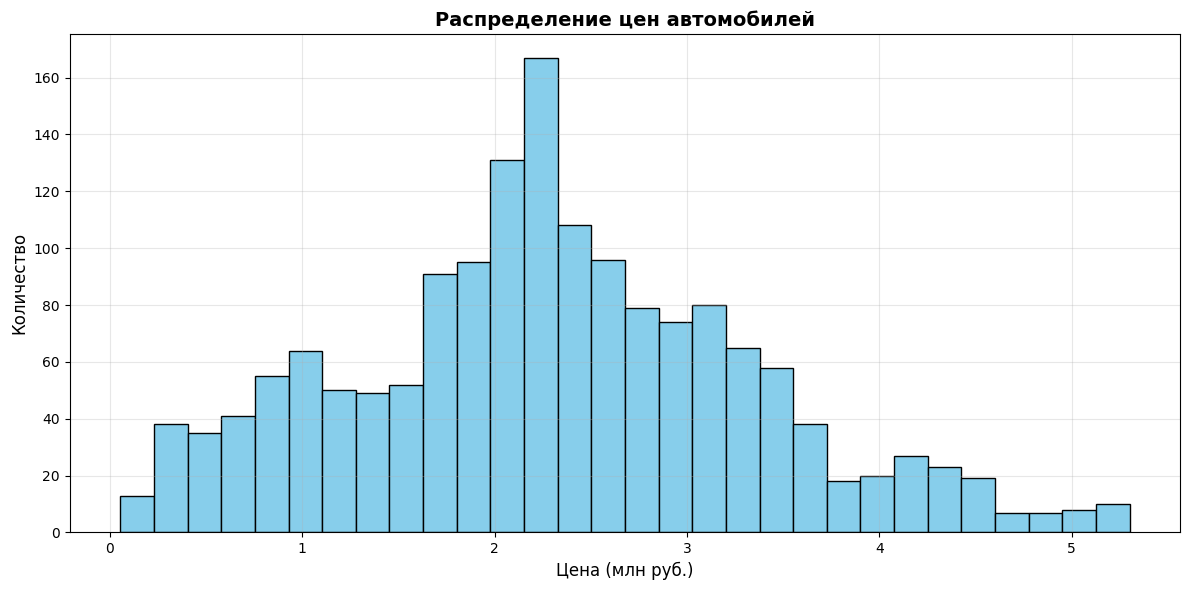

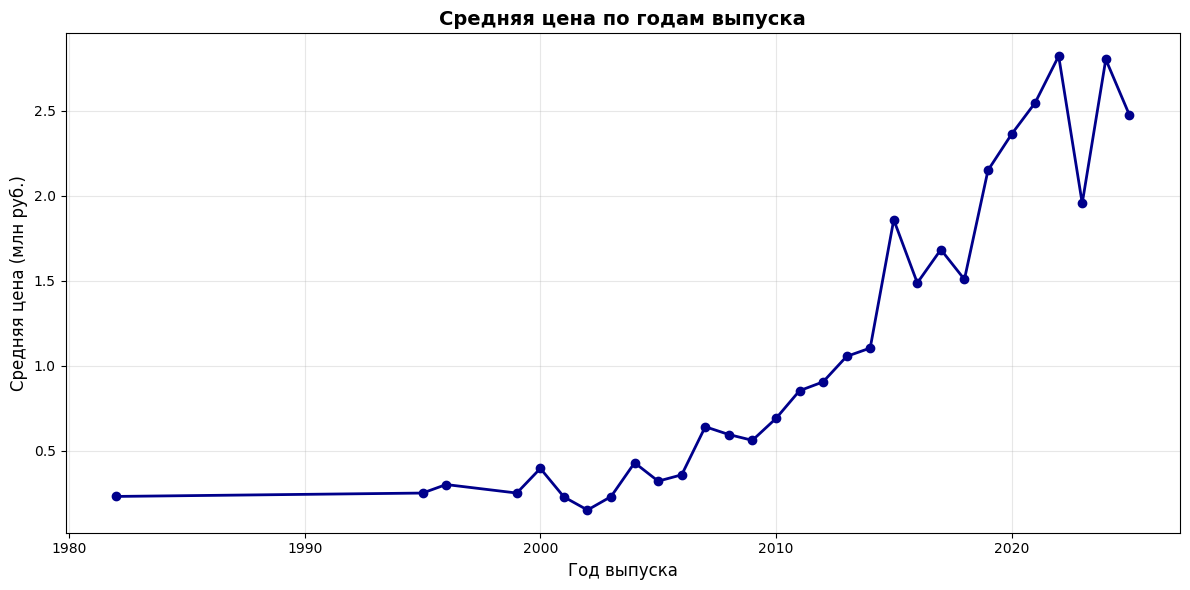

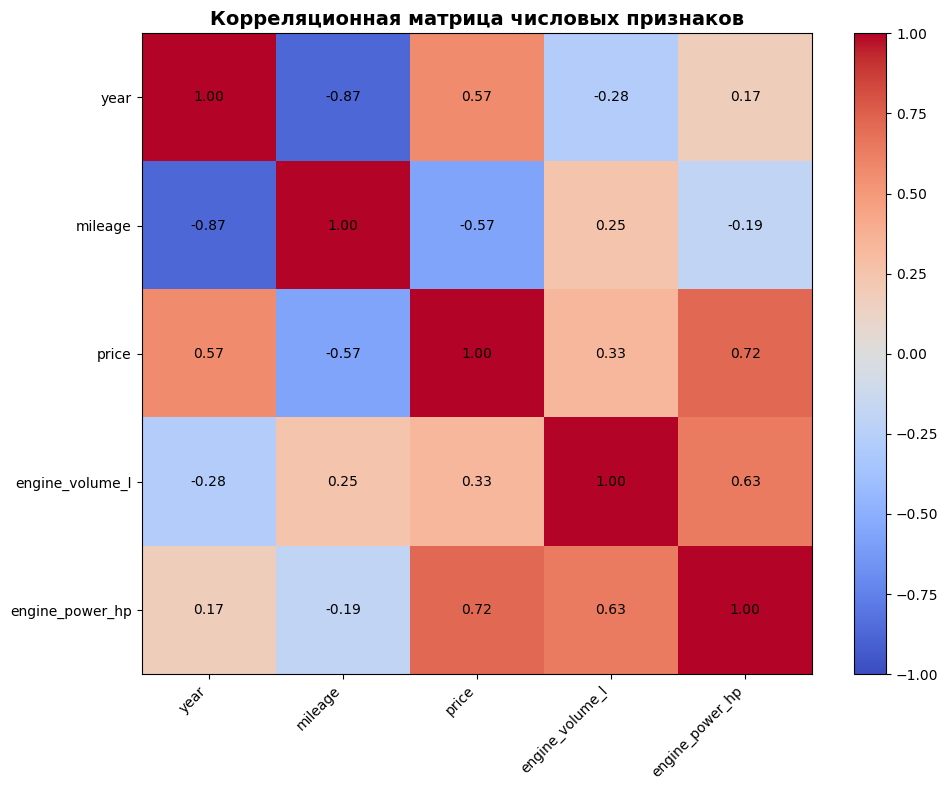

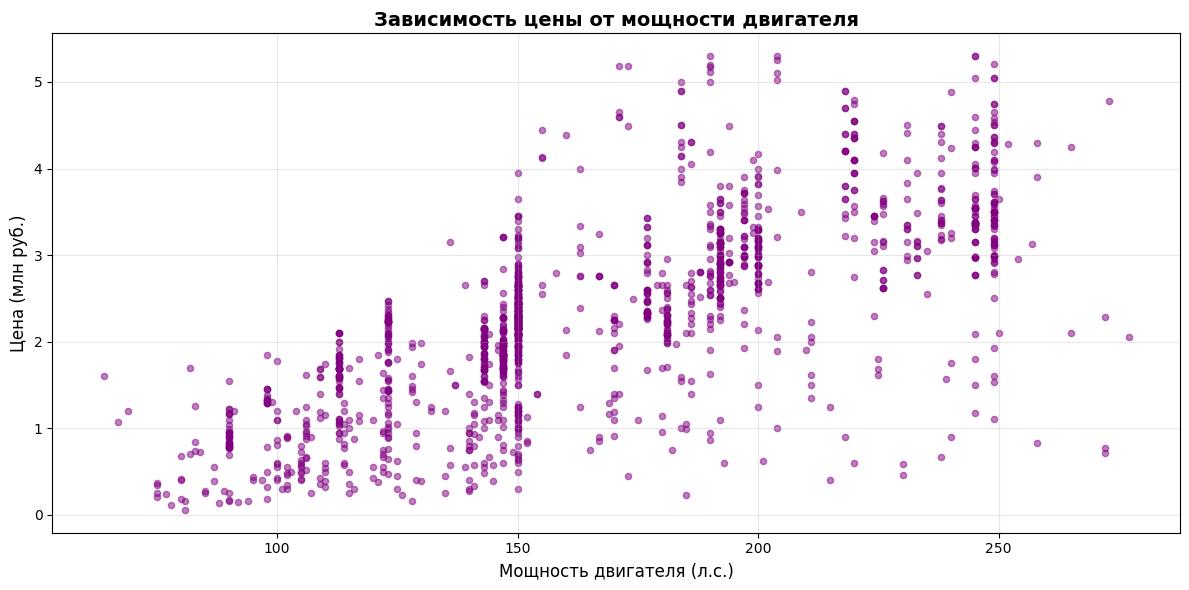

In [6]:
plt.figure(figsize=(12, 6))
plt.hist(df_clean['price'] / 1000000, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Цена (млн руб.)', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение цен автомобилей', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
year_price = df_clean.groupby('year')['price'].mean() / 1000000
plt.plot(year_price.index, year_price.values, marker='o', linewidth=2, 
         markersize=6, color='darkblue')
plt.xlabel('Год выпуска', fontsize=12)
plt.ylabel('Средняя цена (млн руб.)', fontsize=12)
plt.title('Средняя цена по годам выпуска', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_by_year.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = ['year', 'mileage', 'price', 'engine_volume_l', 'engine_power_hp']
correlation = df_clean[numeric_cols].corr()
im = plt.imshow(correlation, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = plt.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10)
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(df_clean['engine_power_hp'], df_clean['price'] / 1000000, 
            alpha=0.5, s=20, color='purple')
plt.xlabel('Мощность двигателя (л.с.)', fontsize=12)
plt.ylabel('Цена (млн руб.)', fontsize=12)
plt.title('Зависимость цены от мощности двигателя', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('price_vs_power.png', dpi=300)
plt.show()

Step 3 Baseline решение с наивной реализацией
- ну просто средняя цена автомобиля 

In [7]:
df = df_encoded
X = df.drop('price', axis=1)
y = df['price']
y_pred_mean = np.full_like(y, y.mean(), dtype=float)

mse = mean_squared_error(y, y_pred_mean)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_mean)

print("Baseline модель")
print(f"Средняя цена: {y.mean():,.0f} руб.")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.0f} руб.")

Baseline модель
Средняя цена: 2,724,399 руб.
MSE: 5,228,237,836,554.94
RMSE: 2,286,534 руб.


Step 4 выбор модели
- очевидно линейная регрессия, т.к. предсказываем цену автомобиля

Step 5 Sklearn 
- выбрал HistGradientBoostingRegressor, потому что хорошая модель с поддержкой ранней остановки(мы же не хотим переобучить модель), мониторингом качества по эпохам (это надо в Step 8), ещё и гистограммы для ускоренного обучения короче кайф

Step 6
- хз какой раздел ~~Речи Посполитой~~ Данных
- хотя валидационные данные для фреймворка не нужно он сам validation_fraction поделит

In [8]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)

Step 7
- Вот тут может долго подбирать (да вы и сами знате), короче перебираем гиперпараметры (Я моб)

In [9]:
param_grid = {
    'max_iter': [300, 350, 400],
    'max_depth': [1, 2, 3],
    'max_leaf_nodes': [2, 3, 4, 5],
    'learning_rate': [0.005, 0.01]
}
rf = HistGradientBoostingRegressor(random_state=40, early_stopping=True, validation_fraction=0.2, n_iter_no_change=10)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print(f'Лучшие параметры: {grid_search.best_params_}')

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 2, 'max_iter': 400, 'max_leaf_nodes': 4}


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 2, 'max_iter': 400, 'max_leaf_nodes': 4}

Step 8 изучаем что наобучали

Обучение - RMSE: 1192890, R2: 0.768
Тест - RMSE: 1002487, R2: 0.704


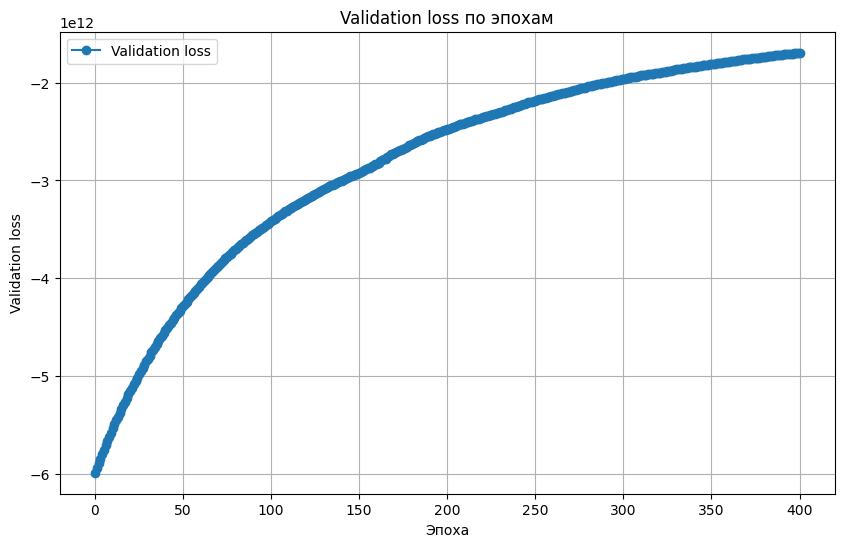

In [10]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print(f'Обучение - RMSE: {rmse_train:.0f}, R2: {r2_train:.3f}')
print(f'Тест - RMSE: {rmse_test:.0f}, R2: {r2_test:.3f}')

if hasattr(model, 'validation_score_'):
    plt.figure(figsize=(10, 6))
    plt.plot(model.validation_score_, marker='o', label='Validation loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Validation loss')
    plt.title('Validation loss по эпохам')
    plt.legend()
    plt.grid(True)
    plt.show()

Обучение - RMSE: 1192890, R2: 0.768
Тест - RMSE: 1002487, R2: 0.704

Модель вроде не переобучена. Значения метрик качества на обучении и валидации находятся близко друг к другу, хотелось бы побольше чем 0.7, но что имеем то имеем

Немного развлечения)
Пихнул 10-летний полик за 929к
пруф если интересно
https://auto.ru/cars/used/sale/volkswagen/polo/1129821298-f8044315/

In [11]:
new_car = {
    'body': 'Седан',
    'wd': 'передний',
    'transmission': 'автоматическая',
    'brand': 'Volkswagen',
    'model' : 'Polo',
    'year' : 2014,
    'mileage': 71000,
    'color_clean': 'Красный',
    'engine_power_hp' : 105,
    'engine_volume_I' : 1.6,
}

Ниже он немного жалуется что лучше таким образом не добавлять, но один раз можно думаю для развлечения. (Спойлер) получилось 980к, как видно достаточно точно(да я знаю что по 1 экземпляру нельзя судить, но просто хотелось поэксперементировать) ладно хватит приколов

In [12]:
new_car_df = pd.DataFrame([new_car])
new_car_df = pd.get_dummies(new_car_df, columns=['body', 'wd', 'transmission', 'brand'], drop_first=True)

for col in X_train.columns:
    if col not in new_car_df.columns:
        new_car_df[col] = 0
new_car_df = new_car_df[X_train.columns]

predicted_price = model.predict(new_car_df)
print(f'Предсказанная цена: {predicted_price[0]:,.0f} руб.')


<ipython-input-12-4a721d4bc4c1>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_car_df[col] = 0
<ipython-input-12-4a721d4bc4c1>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_car_df[col] = 0
<ipython-input-12-4a721d4bc4c1>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_car_df[col] = 

Предсказанная цена: 979,571 руб.


Step 9 Моя модель

In [13]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

class SimpleGradientBoosting:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_leaf=10, tol=10):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.tol = tol
        self.trees = []
        self.init_pred = None

    def fit(self, X, X_val, y, y_val):
        self.init_pred = np.median(y)  # устойчивее к выбросам
        y_pred = np.full(y.shape, self.init_pred)
        self.trees = []
        best_val_loss = float('inf')
        no_improve = 0
        
        for i in range(self.n_estimators):
            residuals = y - y_pred
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X, residuals)
            update = tree.predict(X)
            y_pred += self.learning_rate * update
            self.trees.append(tree)

            val_pred = self.predict(X_val)
            val_loss = np.sqrt(mean_squared_error(y_val, val_pred))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= self.tol:
                    break

    def predict(self, X):
        y_pred = np.full((X.shape[0],), self.init_pred)
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred


Перебираем гиперпараметры

In [46]:
from sklearn.metrics import mean_squared_error
import numpy as np


param_grid = {
    'n_estimators': [180, 200, 220],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'min_samples_leaf': [3, 5, 10, 12],
    'tol' : [5, 10, 15]
}

best_rmse = float('inf')
best_params = None

for n_est in param_grid['n_estimators']:
    for lr in param_grid['learning_rate']:
        for depth in param_grid['max_depth']:
            for min_leaf in param_grid['min_samples_leaf']:
                for tol in param_grid['tol']:
                    model = SimpleGradientBoosting(
                        n_estimators=n_est,
                        learning_rate=lr,
                        max_depth=depth,
                        min_samples_leaf=min_leaf,
                        tol=tol
                    )
                    model.fit(X_train, X_val, y_train, y_val)
                    y_val_pred = model.predict(X_val)
                    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
                    
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_params = {
                            'n_estimators': n_est,
                            'learning_rate': lr,
                            'max_depth': depth,
                            'min_samples_leaf': min_leaf,
                            'tol' : tol,
                        }

print(f"Лучшие параметры: {best_params}")
print(f"Лучший RMSE: {best_rmse:.2f}")


Лучшие параметры: {'n_estimators': 180, 'learning_rate': 0.01, 'max_depth': 9, 'min_samples_leaf': 10, 'tol': 5}
Лучший RMSE: 797175.61


Лучшие параметры: {'n_estimators': 180, 'learning_rate': 0.01, 'max_depth': 9, 'min_samples_leaf': 10, 'tol': 5}
Лучший RMSE: 797175.61

In [ ]:
final_model = SimpleGradientBoosting(**best_params)
final_model.fit(X_train.values, X_val.values, y_train.values, y_val.values)

y_train_pred = final_model.predict(X_train.values)
y_test_pred = final_model.predict(X_test.values)
y_val_pred = final_model.predict(X_val.values)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

print(f"Обучение - RMSE: {rmse_train:.0f}, R2: {r2_train:.3f}")
print(f"Валидация - RMSE: {rmse_val:.0f}, R2: {r2_val:.3f}")
print(f"Тест - RMSE: {rmse_test:.0f}, R2: {r2_test:.3f}")

Обучение - RMSE: 978950, R2: 0.844
Валидация - RMSE: 797040, R2: 0.853
Тест - RMSE: 1054020, R2: 0.673

In [48]:
predicted_price = final_model.predict(new_car_df)
print(f'Предсказанная цена: {predicted_price[0]:,.0f} руб.')

/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fi

Предсказанная цена: 1,194,336 руб.


Step 10
- 

Фреймворковская модель лучше на тестовых данных RMSE: 1002487, R2: 0.704 против RMSE: 1054020, R2: 0.673 у моей модельки неплохо. В принципе предсказать цену не очень просто, особенно учитывая тот факт, что  мы просто не можем обладать данными о тех состоянии автомобиля из-за чего даже для одинаковых по харам авто могут сильно отличаться в цене